## Data Exploration

In [1]:
import os,re
from collections import Counter
import email.policy, email.parser

import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
from wordcloud import WordCloud, STOPWORDS

### Load Datasets

In [2]:
# Load datasets
spam_assassin_datasets = os.path.join("./input", "hamnspam")
ham_folder = os.path.join(spam_assassin_datasets, "ham")
spam_folder = os.path.join(spam_assassin_datasets, "spam")

def load_email(filename):
    with open(filename, "rb") as f:
        return email.parser.BytesParser(policy=email.policy.default).parse(f)

In [3]:
hams_files = [os.path.join(ham_folder, f) for f in sorted(os.listdir(ham_folder))]
spams_files = [os.path.join(spam_folder, f) for f in sorted(os.listdir(spam_folder))]

print(f"Total Number of Ham Data: {len(hams_files)}")
print(f"Total Number of Spam Data: {len(spams_files)}")

hams = [load_email(ham) for ham in hams_files]
spams = [load_email(spam) for spam in spams_files]

def html_to_plain(email):
    try:
        soup = BeautifulSoup(email.get_content(), 'html.parser')
        return soup.text.replace('\n\n','')
    except:
        return "empty"

def email_to_plain(email):
    for part in email.walk():
        content_type = part.get_content_type()
        if content_type == 'text/plain':
            try:
                return part.get_content()
            except:
                return str(part.get_payload())
        if content_type == "text/html":
            return html_to_plain(part)

# str or None
parsed_ham = [email_to_plain(ham) for ham in hams]
parsed_spam = [email_to_plain(spam) for spam in spams]

Total Number of Ham Data: 2551
Total Number of Spam Data: 500


### Preprocessing

In [4]:
def preprocess(text):
    if not text:
        return 'empty'

    # make lowercase
    text = text.lower().strip()

    puncutations = ('.', ',', '!', '?', '-', '+', '(', ')', '{', '}','[', ']', "'", '"', "_", ":", "|", "$", "<", ">", "=", "*", "&", '/', "#", ";")

    # remove puncutation
    for punc in puncutations:
        text = text.replace(punc, '')

    # Remove Email
    text = re.sub("\S*@\S*\s?", ' ', text)

    # Remove URL
    text = re.sub('http\S+',' ', text)
    
    # Remove numbers
    text = re.sub('[0-9]', ' ', text)

    # Remove stopwords
    text = ' '.join([word for word in text.split() if word not in set(STOPWORDS) and len(word) > 1])

    return text

processed_hams = [preprocess(ham) for ham in parsed_ham]
processed_spams = [preprocess(spam) for spam in parsed_spam]

## Wordcloud

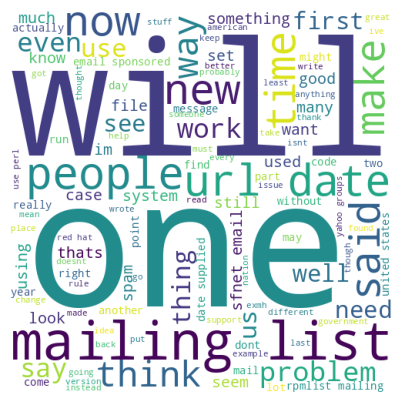

In [5]:
ham_word_cloud = WordCloud(width = 500, height = 500,
                background_color ='white',
                min_font_size = 10).generate(' '.join(processed_hams))

plt.figure(figsize = (5, 5), facecolor = None)
plt.imshow(ham_word_cloud)
plt.axis("off")
plt.show()

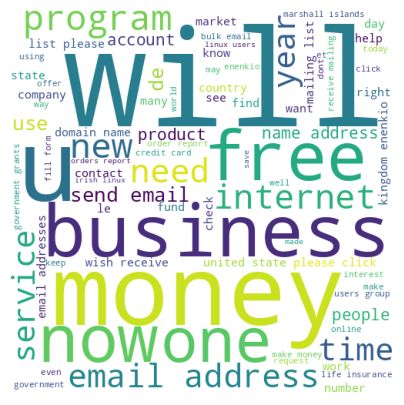

In [6]:
spam_word_cloud = WordCloud(width = 500, height = 500,
                background_color ='white',
                stopwords = set(STOPWORDS),
                min_font_size = 10).generate(' '.join(processed_spams))

plt.figure(figsize = (5, 5), facecolor = None)
plt.imshow(spam_word_cloud)
plt.axis("off")
plt.show()

# Frquency Graph

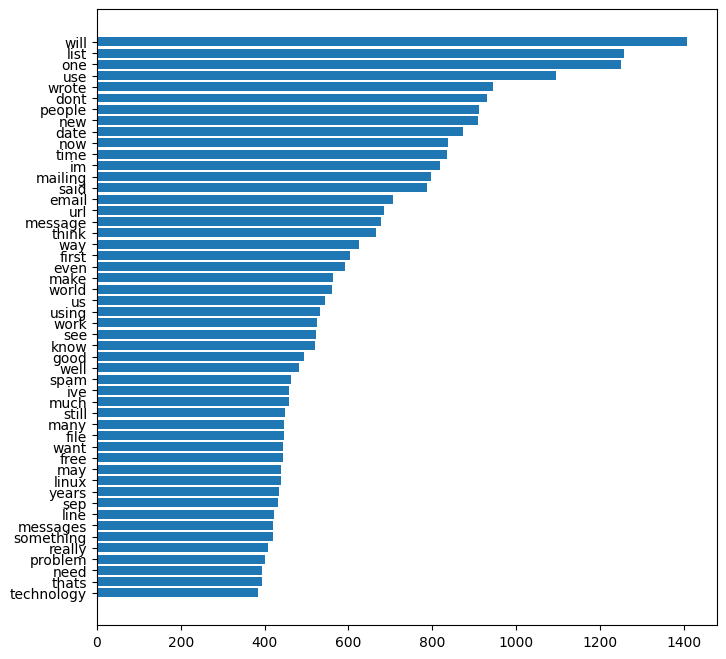

In [10]:
ham_word_counter = Counter(' '.join(processed_hams).split())
most_common_map = ham_word_counter.most_common(50)

words, freq = zip(*reversed(most_common_map))

plt.figure(figsize=(8, 8))
plt.barh(words, freq) 
plt.show()

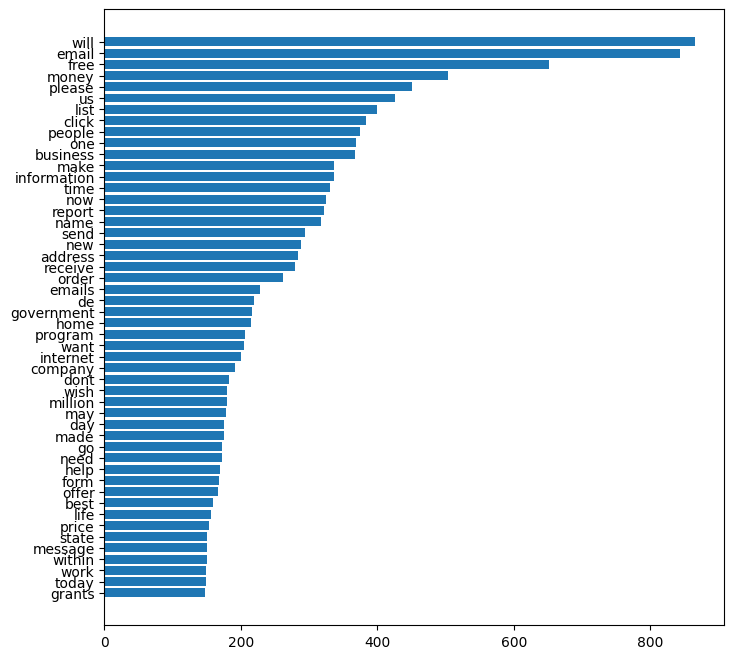

In [11]:
spam_word_counter = Counter(' '.join(processed_spams).split())
most_common_map = spam_word_counter.most_common(50)

words, freq = zip(*reversed(most_common_map))

plt.figure(figsize=(8, 8))
plt.barh(words, freq) 
plt.show()